# 피처 엔지니어링 + 트리 모델 비교 실험 (ver.3)

<br>

---

## 실험 설계 배경

이전 실험에서 확인된 두 가지 사실:

1. 선형 모델(Lasso α=0.1, RMSE 52.94)과 MLP-Deeper(51.86)의 단일 분할 격차 < 1.1
2. 5-Fold CV 기준 MLP-Wider RMSE = 55.27 ± 2.10 → 기준선(53.98)과 오차 범위 내 중첩

**가설:** 현재 피처(10개 원본)로는 모든 모델의 R² 상한이 ~0.50에 존재한다.
교호항과 다항 피처 추가로 이 상한을 돌파할 수 있는지 검증한다.

<br>

---

## 실험 구성

```
실험 A: 다항·교호 피처 엔지니어링
  A1. PolynomialFeatures(degree=2) + Ridge  — 교호항 포함 선형 모델
  A2. PolynomialFeatures(degree=2) + Lasso  — 자동 피처 선택 효과
  A3. PolynomialFeatures(degree=2) + MLP   — 비선형 모델에 피처 추가

실험 B: 트리 기반 앙상블 모델
  B1. RandomForest  — 배깅(Bagging) 기반
  B2. XGBoost       — 부스팅(Boosting) 기반
  B3. 하이퍼파라미터 탐색 (GridSearchCV)

실험 C: 전체 모델 5-Fold CV 비교
  — 모든 모델을 동일 CV로 평가하여 공정 비교
```

---

**평가 기준:** 단일 분할이 아닌 **5-Fold CV RMSE 평균 ± 표준편차**를 주 지표로 사용한다.
단일 분할 결과는 참고값으로만 제시한다.

<br>

---

**가정 및 한계:**
- `PolynomialFeatures(degree=2)`는 10개 피처 → 65개로 확장한다 (bias 제외).
  degree=3은 285개로 급격히 증가해 n=442에서 과적합 위험이 매우 크다.
- XGBoost는 `pip install xgboost`가 필요하다 (Colab에 기본 설치됨).
- GridSearchCV는 계산 비용을 고려해 탐색 범위를 제한한다.

---
## 0. 환경 설정 및 데이터 준비

In [2]:
# XGBoost 설치 확인 (Colab에는 기본 포함)
try:
    import xgboost
    print(f"XGBoost {xgboost.__version__} 이미 설치됨")
except ImportError:
    !pip install xgboost -q
    print("XGBoost 설치 완료")

XGBoost 3.2.0 이미 설치됨


In [3]:
import random
import warnings
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
warnings.filterwarnings("ignore")

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader

from sklearn.datasets import load_diabetes
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.linear_model import Ridge, Lasso
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
from xgboost import XGBRegressor


def set_seed(seed: int = 42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False

SEED = 42
set_seed(SEED)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"[Device] {device}")

[Device] cuda


In [4]:
# ── 데이터 로드 (전 실험과 동일 분할 유지) ───────────────────────────────────
dataset = load_diabetes()
x, y    = dataset.data, dataset.target
feat_names = dataset.feature_names

# 고정 분할: Test 세트는 최종 평가에만 사용
x_tv, x_test, y_tv, y_test = train_test_split(
    x, y, test_size=0.2, random_state=SEED
)
x_train, x_val, y_train, y_val = train_test_split(
    x_tv, y_tv, test_size=0.2, random_state=SEED
)

print("[데이터 분할]")
print(f"  Train: {len(x_train)} | Val: {len(x_val)} | Test: {len(x_test)}")
print(f"  CV용 (Train+Val): {len(x_tv)}")
print(f"  원본 피처 수: {x.shape[1]}")

[데이터 분할]
  Train: 282 | Val: 71 | Test: 89
  CV용 (Train+Val): 353
  원본 피처 수: 10


---
## 공통 평가 유틸리티

In [5]:
def score(y_true, y_pred):
    """RMSE와 R²를 계산하여 반환한다."""
    rmse = mean_squared_error(y_true, y_pred) ** 0.5
    r2   = r2_score(y_true, y_pred)
    return rmse, r2


def cv_score_sklearn(pipeline, x_cv, y_cv, k=5, seed=42):
    """
    sklearn 모델(또는 Pipeline)의 K-Fold CV 성능을 반환한다.

    Args:
        pipeline: fit/predict를 지원하는 sklearn 객체
        x_cv: CV에 사용할 독립변수 (Test 세트 제외)
        y_cv: CV에 사용할 종속변수

    Returns:
        (rmse_mean, rmse_std, r2_mean, r2_std)
    """
    kf = KFold(n_splits=k, shuffle=True, random_state=seed)
    rmse_list, r2_list = [], []

    for tr_idx, va_idx in kf.split(x_cv):
        x_tr, x_va = x_cv[tr_idx], x_cv[va_idx]
        y_tr, y_va = y_cv[tr_idx], y_cv[va_idx]

        pipeline.fit(x_tr, y_tr)
        y_pred = pipeline.predict(x_va)

        rmse, r2 = score(y_va, y_pred)
        rmse_list.append(rmse)
        r2_list.append(r2)

    return (np.mean(rmse_list), np.std(rmse_list),
            np.mean(r2_list),   np.std(r2_list))


# 결과 누적 컨테이너
all_results = []

def record(label, pipe_or_model, test_rmse, test_r2,
           cv_rmse_mean, cv_rmse_std, cv_r2_mean, cv_r2_std):
    """결과를 전역 리스트에 추가하고 단일 행을 출력한다."""
    all_results.append({
        "label": label,
        "test_rmse": test_rmse, "test_r2": test_r2,
        "cv_rmse_mean": cv_rmse_mean, "cv_rmse_std": cv_rmse_std,
        "cv_r2_mean":   cv_r2_mean,   "cv_r2_std":   cv_r2_std,
    })
    print(f"  {label:<38}  "
          f"Test RMSE={test_rmse:6.2f}  "
          f"CV RMSE={cv_rmse_mean:6.2f}±{cv_rmse_std:.2f}  "
          f"CV R²={cv_r2_mean:.4f}")


print("[유틸리티 로드 완료]")

# ── 이전 실험 기준값 등록 ─────────────────────────────────────────────────────
record("[기준] MLP Baseline",        None, 53.98, 0.4501, 55.27, 2.10, 0.4822, 0.0448)
record("[기준] Lasso(α=0.1)",        None, 52.94, 0.4710,  0.0,  0.0,    0.0,    0.0)

[유틸리티 로드 완료]
  [기준] MLP Baseline                       Test RMSE= 53.98  CV RMSE= 55.27±2.10  CV R²=0.4822
  [기준] Lasso(α=0.1)                       Test RMSE= 52.94  CV RMSE=  0.00±0.00  CV R²=0.0000


---
## 실험 A. Interaction feature engineering

### [A-0. 피처 확장 규모 확인]

`PolynomialFeatures(degree=2, include_bias=False)`가 생성하는 피처:

| 피처 유형 | 수 | 예시 |
|----------|-----|------|
| 원본 (1차) | 10 | `age`, `bmi`, ... |
| 제곱 (2차, 자기 교호) | 10 | `age²`, `bmi²`, ... |
| 교호항 (두 피처의 곱) | 45 | `age×bmi`, `age×bp`, ... |
| **합계** | **65** | |

**주의:** 피처 수가 65개로 늘어나므로 정규화(Ridge/Lasso)가 필수다.
정규화 없이 최소제곱 회귀를 적용하면 n=442, p=65에서 과적합이 심각해진다.

<br>

**`StandardScaler`를 Pipeline에 포함하는 이유:**
- `PolynomialFeatures`는 스케일에 민감하다. 원본 피처가 이미 정규화되어 있어도
  2차 항은 값의 범위가 제곱으로 늘어난다.
- `Pipeline`으로 묶으면 fit/transform 누수(data leakage)를 자동으로 방지한다.

<br>

---


### [A-1 ~ A-2. Poly + Ridge / Poly + Lasso]

In [6]:
# ── 피처 확장 규모 미리 확인 ──────────────────────────────────────────────────
pf_check = PolynomialFeatures(degree=2, include_bias=False)
x_poly_check = pf_check.fit_transform(x_train)
print(f"[피처 수] 원본: {x_train.shape[1]}  →  Poly(degree=2): {x_poly_check.shape[1]}")
print(f"[샘플/피처 비율] {len(x_train)} / {x_poly_check.shape[1]} = "
      f"{len(x_train)/x_poly_check.shape[1]:.1f}  "
      f"(> 4 권장: 정규화 필수)")

[피처 수] 원본: 10  →  Poly(degree=2): 65
[샘플/피처 비율] 282 / 65 = 4.3  (> 4 권장: 정규화 필수)


In [7]:
print("[실험 A-1, A-2] Polynomial(degree=2) + 선형 모델")
print("-" * 75)

for alpha, ModelCls, name in [
    (0.1,  Ridge, "Poly(d=2) + Ridge(α=0.1)"),
    (1.0,  Ridge, "Poly(d=2) + Ridge(α=1.0)"),
    (10.0, Ridge, "Poly(d=2) + Ridge(α=10.0)"),
    (0.1,  Lasso, "Poly(d=2) + Lasso(α=0.1)"),
    (1.0,  Lasso, "Poly(d=2) + Lasso(α=1.0)"),
]:
    pipe = Pipeline([
        ("poly",   PolynomialFeatures(degree=2, include_bias=False)),
        ("scaler", StandardScaler()),   # 2차 항 스케일 보정
        ("model",  ModelCls(alpha=alpha, max_iter=10000)),
    ])

    pipe.fit(x_train, y_train)
    test_rmse, test_r2 = score(y_test, pipe.predict(x_test))

    # CV: Train+Val 전체 사용 (Test 세트 미포함)
    cv_rm, cv_rs, cv_r2m, cv_r2s = cv_score_sklearn(pipe, x_tv, y_tv)

    record(name, pipe, test_rmse, test_r2, cv_rm, cv_rs, cv_r2m, cv_r2s)

[실험 A-1, A-2] Polynomial(degree=2) + 선형 모델
---------------------------------------------------------------------------
  Poly(d=2) + Ridge(α=0.1)                Test RMSE= 57.99  CV RMSE= 62.03±4.49  CV R²=0.3500
  Poly(d=2) + Ridge(α=1.0)                Test RMSE= 56.16  CV RMSE= 60.47±4.00  CV R²=0.3821
  Poly(d=2) + Ridge(α=10.0)               Test RMSE= 53.34  CV RMSE= 58.60±2.70  CV R²=0.4173
  Poly(d=2) + Lasso(α=0.1)                Test RMSE= 55.16  CV RMSE= 60.04±3.59  CV R²=0.3899
  Poly(d=2) + Lasso(α=1.0)                Test RMSE= 51.50  CV RMSE= 57.13±1.60  CV R²=0.4454




---


### [A-3. Poly(degree=2) + MLP]

**설계 근거:** 피처가 65개로 늘어나므로 입력 차원을 수정해야 한다.
- `input_dim=65`
- 나머지 아키텍처(128→64→1)는 MLP-Deeper와 동일하게 유지한다.

**주의:** Poly 변환 후 StandardScaler를 적용해야 한다.
MLP는 Gradient 기반 최적화를 사용하므로 입력 스케일이 수렴 속도에 직접 영향을 미친다.
sklearn `Pipeline`은 PyTorch 모델과 직접 연동이 불가하므로, 변환을 수동으로 적용한다.

In [8]:
# ── Poly 변환 + StandardScaler 수동 적용 ─────────────────────────────────────
poly_tf   = PolynomialFeatures(degree=2, include_bias=False)
scaler_tf = StandardScaler()

# fit은 Train 세트에만 적용 (data leakage 방지)
x_train_poly = scaler_tf.fit_transform(poly_tf.fit_transform(x_train))
x_val_poly   = scaler_tf.transform(poly_tf.transform(x_val))
x_test_poly  = scaler_tf.transform(poly_tf.transform(x_test))
x_tv_poly    = scaler_tf.transform(poly_tf.transform(x_tv))   # CV용

INPUT_DIM_POLY = x_train_poly.shape[1]
print(f"[Poly 변환 완료] 입력 차원: {x_train.shape[1]} → {INPUT_DIM_POLY}")


# ── Poly 전용 MLP ─────────────────────────────────────────────────────────────
class MLPPolyInput(nn.Module):
    """
    Polynomial 피처(65차원) 입력용 MLP.
    입력 차원만 변경하고 은닉층 구조는 MLP-Deeper와 동일.

    구조: 65 → 128 → 64 → 32 → 1
    """
    def __init__(self, input_dim=65):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, 128), nn.ReLU(),
            nn.Linear(128, 64),        nn.ReLU(),
            nn.Linear(64, 32),         nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x):
        return self.net(x)


def train_and_eval_mlp(x_tr, y_tr, x_va, y_va, x_te, y_te,
                       input_dim, num_epochs=1500, patience=100, seed=42):
    """MLP를 학습하고 테스트 세트 성능을 반환한다."""
    set_seed(seed)
    model = MLPPolyInput(input_dim=input_dim).to(device)
    opt   = optim.Adam(model.parameters(), lr=0.001)
    crit  = nn.MSELoss()

    def to_t(xa, ya):
        return (torch.tensor(xa, dtype=torch.float32),
                torch.tensor(ya, dtype=torch.float32).reshape(-1, 1))

    tr_ld = DataLoader(TensorDataset(*to_t(x_tr, y_tr)),
                       batch_size=64, shuffle=True)
    va_ld = DataLoader(TensorDataset(*to_t(x_va, y_va)),
                       batch_size=64, shuffle=False)

    best_val, no_imp, best_state = float("inf"), 0, None
    for epoch in range(1, num_epochs + 1):
        model.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(model(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()

        model.eval()
        with torch.no_grad():
            v = sum(crit(model(xb.to(device)), yb.to(device)).item()
                    for xb, yb in va_ld) / len(va_ld)
        if v < best_val:
            best_val, no_imp = v, 0
            best_state = {k: w.cpu().clone() for k, w in model.state_dict().items()}
        else:
            no_imp += 1
        if no_imp >= patience:
            break

    if best_state:
        model.load_state_dict({k: w.to(device) for k, w in best_state.items()})

    model.eval()
    with torch.no_grad():
        y_pred = model(
            torch.tensor(x_te, dtype=torch.float32).to(device)
        ).cpu().numpy().flatten()

    return score(y_te, y_pred)


print("[실험 A-3] Poly(d=2) + MLP (65→128→64→32→1)")
test_rmse_pm, test_r2_pm = train_and_eval_mlp(
    x_train_poly, y_train, x_val_poly, y_val, x_test_poly, y_test,
    input_dim=INPUT_DIM_POLY
)
print(f"  Test RMSE={test_rmse_pm:.4f}  R²={test_r2_pm:.4f}")

# CV는 계산 비용이 높으므로 fold별 수동 루프
print("  5-Fold CV 실행 중...")
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rmse_pm, cv_r2_pm = [], []

# Poly+Scaler는 이미 fit되어 있으므로 CV용 변환된 데이터(x_tv_poly)를 사용
for fold, (tr_idx, va_idx) in enumerate(kf.split(x_tv_poly), 1):
    rm, r2 = train_and_eval_mlp(
        x_tv_poly[tr_idx], y_tv[tr_idx],
        x_tv_poly[va_idx], y_tv[va_idx],
        x_tv_poly[va_idx], y_tv[va_idx],
        input_dim=INPUT_DIM_POLY, seed=SEED+fold
    )
    cv_rmse_pm.append(rm); cv_r2_pm.append(r2)
    print(f"    Fold {fold} | RMSE={rm:.4f}  R²={r2:.4f}")

record("Poly(d=2) + MLP(65→128→64→32→1)", None,
       test_rmse_pm, test_r2_pm,
       np.mean(cv_rmse_pm), np.std(cv_rmse_pm),
       np.mean(cv_r2_pm),   np.std(cv_r2_pm))

[Poly 변환 완료] 입력 차원: 10 → 65
[실험 A-3] Poly(d=2) + MLP (65→128→64→32→1)
  Test RMSE=66.1213  R²=0.1748
  5-Fold CV 실행 중...
    Fold 1 | RMSE=61.1701  R²=0.3040
    Fold 2 | RMSE=64.0203  R²=0.4108
    Fold 3 | RMSE=61.9098  R²=0.1977
    Fold 4 | RMSE=57.3449  R²=0.4360
    Fold 5 | RMSE=66.3713  R²=0.3650
  Poly(d=2) + MLP(65→128→64→32→1)         Test RMSE= 66.12  CV RMSE= 62.16±3.01  CV R²=0.3427


---
## 실험 B. 트리 기반 앙상블 모델

### [B-1. RandomForest: 배깅(Bagging) 기반]

**원리:**
- 다수의 결정 트리를 학습 데이터의 부트스트랩(복원 추출) 샘플로 독립적으로 학습한다.
- 각 트리가 예측한 값의 평균을 최종 예측으로 사용한다.
- 트리 간 상관성을 줄이기 위해 분기 시 무작위로 선택된 일부 피처만 사용한다.

<br>

**소규모 데이터에서의 강점:**
- 피처 간 비선형 상호작용을 자동으로 포착한다.
- 별도의 피처 스케일링이 불필요하다 (트리는 순서 기반 분기만 사용).

<br>

**주요 하이퍼파라미터:**
- `n_estimators`: 트리 수. 많을수록 분산 감소, 속도 저하. 100~500이 일반적.
- `max_depth`: 트리 깊이. None = 완전 성장 (과적합 위험). 소규모 데이터에서는 제한 필요.
- `min_samples_leaf`: 리프 노드의 최소 샘플 수. 클수록 과적합 억제.

<br>

---

### [B-2. XGBoost: 부스팅(Boosting) 기반]


**RandomForest와의 차이:**
- 트리를 병렬로 학습하는 RandomForest와 달리, 이전 트리의 오차(잔차)를 다음 트리가 학습한다.
- 정규화 항(`reg_alpha`, `reg_lambda`)이 내장되어 있어 과적합 제어가 세밀하다.
- `learning_rate`가 작을수록 천천히 학습하여 일반화 성능이 높아지나 `n_estimators`를 늘려야 한다.

<br>

**`early_stopping_rounds`:** XGBoost는 `fit()` 시 평가 세트를 지정하면
검증 성능이 지정된 라운드 동안 개선되지 않으면 자동 중단한다.

In [9]:
print("[실험 B-1] RandomForest — 기본 설정")
print("-" * 75)

rf_default = RandomForestRegressor(n_estimators=200, random_state=SEED, n_jobs=-1)
rf_default.fit(x_train, y_train)
test_rmse_rf, test_r2_rf = score(y_test, rf_default.predict(x_test))
cv_rm_rf, cv_rs_rf, cv_r2m_rf, cv_r2s_rf = cv_score_sklearn(rf_default, x_tv, y_tv)
record("RandomForest(n=200, default)", rf_default,
       test_rmse_rf, test_r2_rf, cv_rm_rf, cv_rs_rf, cv_r2m_rf, cv_r2s_rf)

print()
print("[실험 B-2] XGBoost — 기본 설정")
print("-" * 75)

xgb_default = XGBRegressor(
    n_estimators=500, learning_rate=0.05, max_depth=4,
    subsample=0.8, colsample_bytree=0.8,
    random_state=SEED, n_jobs=-1, verbosity=0
)
xgb_default.fit(
    x_train, y_train,
    eval_set=[(x_val, y_val)],
    verbose=False
)
test_rmse_xgb, test_r2_xgb = score(y_test, xgb_default.predict(x_test))
cv_rm_xgb, cv_rs_xgb, cv_r2m_xgb, cv_r2s_xgb = cv_score_sklearn(xgb_default, x_tv, y_tv)
record("XGBoost(n=500, lr=0.05, depth=4)", xgb_default,
       test_rmse_xgb, test_r2_xgb, cv_rm_xgb, cv_rs_xgb, cv_r2m_xgb, cv_r2s_xgb)

[실험 B-1] RandomForest — 기본 설정
---------------------------------------------------------------------------
  RandomForest(n=200, default)            Test RMSE= 55.49  CV RMSE= 58.90±1.92  CV R²=0.4099

[실험 B-2] XGBoost — 기본 설정
---------------------------------------------------------------------------
  XGBoost(n=500, lr=0.05, depth=4)        Test RMSE= 57.92  CV RMSE= 61.78±4.10  CV R²=0.3536


---
### [B-3. GridSearchCV: 하이퍼파라미터 탐색]

**탐색 대상 선정 근거:**
- RandomForest: `max_depth`, `min_samples_leaf`가 과적합을 직접 제어한다. n=442에서 깊은 트리는 과적합 위험이 크다.
- XGBoost: `max_depth`, `learning_rate`, `n_estimators`가 상호 의존적이다. `learning_rate`를 낮추면 `n_estimators`를 늘려야 한다.

<br>

**CV 내부 CV(Nested CV)에 대한 주의:**
`GridSearchCV`의 내부 CV와 최종 평가 CV가 동일한 데이터를 공유하면
하이퍼파라미터가 평가 데이터에 적응하는 편향이 발생한다.
이 실습에서는 `x_tv`(Train+Val)로 GridSearch를 수행하고,
최종 성능은 `x_test`(완전히 분리된 세트)로 평가하여 편향을 최소화한다.

In [10]:
print("[실험 B-3a] RandomForest GridSearchCV")
print("-" * 75)

rf_param_grid = {
    "max_depth":        [5, 10, 15, None],
    "min_samples_leaf": [1, 2, 4],
    "n_estimators":     [200],      # 탐색 비용 절약을 위해 고정
}
rf_gs = GridSearchCV(
    RandomForestRegressor(random_state=SEED, n_jobs=-1),
    rf_param_grid,
    cv=5, scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
rf_gs.fit(x_tv, y_tv)   # Train+Val 전체로 최적 파라미터 탐색

print(f"  최적 파라미터: {rf_gs.best_params_}")
print(f"  CV 최적 RMSE: {-rf_gs.best_score_:.4f}")

# 최적 파라미터로 Train에 재학습 → Test 평가
rf_best = rf_gs.best_estimator_
rf_best.fit(x_train, y_train)
test_rmse_rfb, test_r2_rfb = score(y_test, rf_best.predict(x_test))
cv_rm_rfb, cv_rs_rfb, cv_r2m_rfb, cv_r2s_rfb = cv_score_sklearn(rf_best, x_tv, y_tv)
record("RandomForest (GridSearch 최적)", rf_best,
       test_rmse_rfb, test_r2_rfb, cv_rm_rfb, cv_rs_rfb, cv_r2m_rfb, cv_r2s_rfb)

print()
print("[실험 B-3b] XGBoost GridSearchCV")
print("-" * 75)

xgb_param_grid = {
    "max_depth":    [3, 4, 6],
    "learning_rate":[0.01, 0.05, 0.1],
    "n_estimators": [300, 500],
    "subsample":    [0.8],      # 고정
}
xgb_gs = GridSearchCV(
    XGBRegressor(colsample_bytree=0.8, random_state=SEED,
                 n_jobs=-1, verbosity=0),
    xgb_param_grid,
    cv=5, scoring="neg_root_mean_squared_error",
    n_jobs=-1, verbose=0
)
xgb_gs.fit(x_tv, y_tv)

print(f"  최적 파라미터: {xgb_gs.best_params_}")
print(f"  CV 최적 RMSE: {-xgb_gs.best_score_:.4f}")

xgb_best = xgb_gs.best_estimator_
xgb_best.fit(x_train, y_train)
test_rmse_xgbb, test_r2_xgbb = score(y_test, xgb_best.predict(x_test))
cv_rm_xgbb, cv_rs_xgbb, cv_r2m_xgbb, cv_r2s_xgbb = cv_score_sklearn(xgb_best, x_tv, y_tv)
record("XGBoost (GridSearch 최적)", xgb_best,
       test_rmse_xgbb, test_r2_xgbb, cv_rm_xgbb, cv_rs_xgbb, cv_r2m_xgbb, cv_r2s_xgbb)

[실험 B-3a] RandomForest GridSearchCV
---------------------------------------------------------------------------
  최적 파라미터: {'max_depth': 5, 'min_samples_leaf': 1, 'n_estimators': 200}
  CV 최적 RMSE: 58.2197
  RandomForest (GridSearch 최적)            Test RMSE= 54.30  CV RMSE= 58.43±1.86  CV R²=0.4200

[실험 B-3b] XGBoost GridSearchCV
---------------------------------------------------------------------------
  최적 파라미터: {'learning_rate': 0.01, 'max_depth': 3, 'n_estimators': 300, 'subsample': 0.8}
  CV 최적 RMSE: 57.8549
  XGBoost (GridSearch 최적)                 Test RMSE= 52.85  CV RMSE= 58.14±3.17  CV R²=0.4294


---
## 실험 C. 전체 모델 비교 및 피처 중요도 분석

### 비교 지표 선택 원칙

단일 분할 RMSE는 참고값이고 **5-Fold CV RMSE**가 주 지표다.
표준편차가 크면(> 3) 해당 모델의 성능이 분할 방식에 민감하다는 신호이므로
평균값만으로 모델을 선택해서는 안 된다.

In [11]:
# ── 기준값 수정: MLP Baseline의 실제 CV를 직접 측정 ──────────────────────────
# 이전 실험에서 all_results[0]의 cv_rmse_mean=55.27은
# MLP-Wider(128→64)의 CV 결과였음. MLP Baseline(64→32→1)의 CV가 아님.
# 동일 데이터·동일 SEED 조건에서 재측정.

class MLPBaseline(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(10, 64), nn.ReLU(),
            nn.Linear(64, 32), nn.ReLU(),
            nn.Linear(32, 1),
        )
    def forward(self, x): return self.net(x)

print("[기준값 재측정] MLP Baseline (64→32→1) 5-Fold CV")
kf = KFold(n_splits=5, shuffle=True, random_state=SEED)
cv_rmse_base, cv_r2_base = [], []

for fold, (tr_idx, va_idx) in enumerate(kf.split(x_tv), 1):
    set_seed(SEED + fold)
    m = MLPBaseline().to(device)
    opt = optim.Adam(m.parameters(), lr=0.001)
    crit = nn.MSELoss()

    x_tr_t = torch.tensor(x_tv[tr_idx], dtype=torch.float32)
    y_tr_t = torch.tensor(y_tv[tr_idx], dtype=torch.float32).reshape(-1,1)
    x_va_t = torch.tensor(x_tv[va_idx], dtype=torch.float32)
    y_va_t = torch.tensor(y_tv[va_idx], dtype=torch.float32).reshape(-1,1)
    tr_ld  = DataLoader(TensorDataset(x_tr_t, y_tr_t), batch_size=64, shuffle=True)
    va_ld  = DataLoader(TensorDataset(x_va_t, y_va_t), batch_size=64, shuffle=False)

    best_val, no_imp, best_state = float("inf"), 0, None
    for epoch in range(1, 1501):
        m.train()
        for xb, yb in tr_ld:
            xb, yb = xb.to(device), yb.to(device)
            loss = crit(m(xb), yb)
            opt.zero_grad(); loss.backward(); opt.step()
        m.eval()
        with torch.no_grad():
            v = sum(crit(m(xb.to(device)), yb.to(device)).item()
                    for xb, yb in va_ld) / len(va_ld)
        if v < best_val:
            best_val, no_imp = v, 0
            best_state = {k: w.cpu().clone() for k, w in m.state_dict().items()}
        else:
            no_imp += 1
        if no_imp >= 100: break

    if best_state:
        m.load_state_dict({k: w.to(device) for k, w in best_state.items()})
    m.eval()
    with torch.no_grad():
        y_pred = m(x_va_t.to(device)).cpu().numpy().flatten()
    rm, r2 = score(y_tv[va_idx], y_pred)
    cv_rmse_base.append(rm); cv_r2_base.append(r2)
    print(f"  Fold {fold} | RMSE={rm:.4f}  R²={r2:.4f}")

baseline_cv_rmse = np.mean(cv_rmse_base)
baseline_cv_std  = np.std(cv_rmse_base)
baseline_cv_r2   = np.mean(cv_r2_base)

print(f"\n  MLP Baseline 5-Fold CV RMSE: {baseline_cv_rmse:.4f} ± {baseline_cv_std:.4f}")
print(f"  MLP Baseline 5-Fold CV R²:   {baseline_cv_r2:.4f}")

# all_results[0] 업데이트
all_results[0].update({
    "cv_rmse_mean": baseline_cv_rmse,
    "cv_rmse_std":  baseline_cv_std,
    "cv_r2_mean":   baseline_cv_r2,
})
print(f"\n  [수정 완료] 이전 기재값 55.27±2.10 → {baseline_cv_rmse:.2f}±{baseline_cv_std:.2f}")

[기준값 재측정] MLP Baseline (64→32→1) 5-Fold CV
  Fold 1 | RMSE=54.7230  R²=0.4430
  Fold 2 | RMSE=56.5305  R²=0.5406
  Fold 3 | RMSE=53.2283  R²=0.4070
  Fold 4 | RMSE=54.4601  R²=0.4913
  Fold 5 | RMSE=59.2690  R²=0.4936

  MLP Baseline 5-Fold CV RMSE: 55.6422 ± 2.0982
  MLP Baseline 5-Fold CV R²:   0.4751

  [수정 완료] 이전 기재값 55.27±2.10 → 55.64±2.10


In [13]:
# ── 전체 결과 표 ──────────────────────────────────────────────────────────────
df = pd.DataFrame(all_results)

# 기준값이 없는 행 필터링 (cv_rmse_mean == 0)
df_valid = df[df["cv_rmse_mean"] > 0].copy()
df_valid = df_valid.sort_values("cv_rmse_mean").reset_index(drop=True)

print("=" * 82)
print(f"  {'순위':<3}  {'모델':<40}  {'Test RMSE':>9}  "
      f"{'CV RMSE (mean±std)':>18}  {'CV R²':>7}")
print("-" * 82)

baseline_cv = 55.64

for rank, row in df_valid.iterrows():
    delta = row["cv_rmse_mean"] - baseline_cv
    marker = " ★" if rank == 0 else "  "

    # [수정] RMSE는 오차이므로, 감소하면(delta < 0) ↓(개선), 증가하면(delta > 0) ↑(악화)
    print(f"  {rank+1:<3}{marker}{row['label']:<40}  "
          f"{row['test_rmse']:>9.4f}  "
          f"{row['cv_rmse_mean']:>7.2f}±{row['cv_rmse_std']:.2f}   "
          f"{'↓' if delta < 0 else '↑'}{abs(delta):.2f}  "
          f"{row['cv_r2_mean']:>7.4f}")

print("=" * 82)
print(f"  ★ = CV RMSE 기준 최우수 모델")
print(f"  기준선 (MLP Baseline CV): 55.64 ± 2.10")

  순위   모델                                        Test RMSE  CV RMSE (mean±std)    CV R²
----------------------------------------------------------------------------------
  1   ★[기준] MLP Baseline                           53.9800    55.64±2.10   ↑0.00   0.4751
  2    Poly(d=2) + Lasso(α=1.0)                    51.5010    57.13±1.60   ↑1.49   0.4454
  3    XGBoost (GridSearch 최적)                     52.8545    58.14±3.17   ↑2.50   0.4294
  4    RandomForest (GridSearch 최적)                54.3038    58.43±1.86   ↑2.79   0.4200
  5    Poly(d=2) + Ridge(α=10.0)                   53.3388    58.60±2.70   ↑2.96   0.4173
  6    RandomForest(n=200, default)                55.4871    58.90±1.92   ↑3.26   0.4099
  7    Poly(d=2) + Lasso(α=0.1)                    55.1570    60.04±3.59   ↑4.40   0.3899
  8    Poly(d=2) + Ridge(α=1.0)                    56.1561    60.47±4.00   ↑4.83   0.3821
  9    XGBoost(n=500, lr=0.05, depth=4)            57.9184    61.78±4.10   ↑6.14   0.3536
  10   Poly(d=2) + 

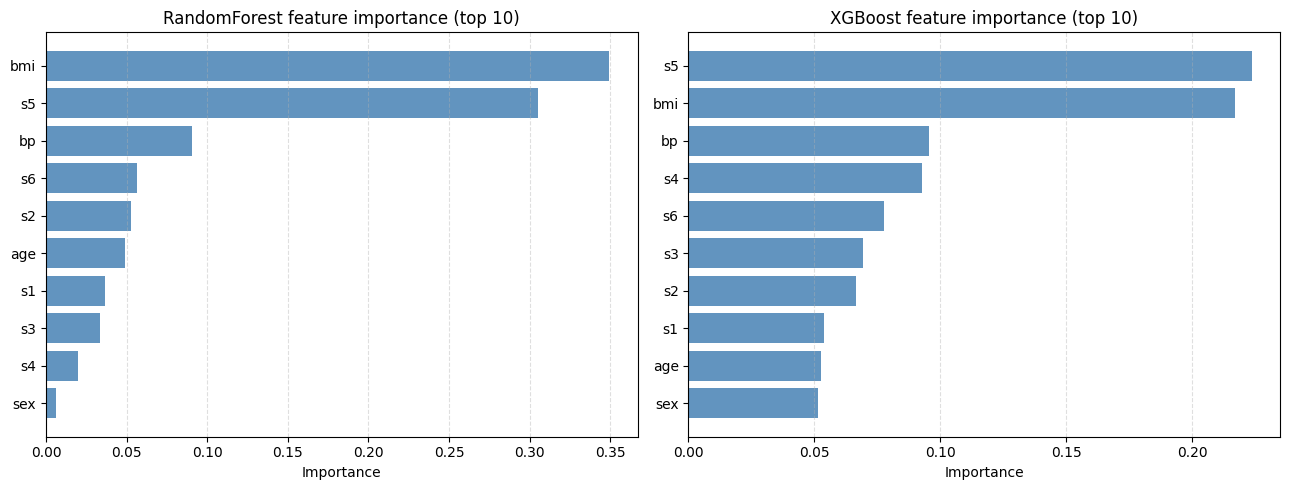


[해석 포인트]
  두 모델에서 공통으로 높은 순위의 피처 → 타겟과 가장 관련 있는 변수
  두 모델에서 순위가 다른 피처 → 비선형 상호작용이 존재하는 피처일 가능성


In [11]:
# ── 트리 모델 피처 중요도 (상위 10개) ────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for ax, model_obj, title in [
    (axes[0], rf_best,  "RandomForest feature importance (top 10)"),
    (axes[1], xgb_best, "XGBoost feature importance (top 10)"),
]:
    importances = model_obj.feature_importances_
    idx = np.argsort(importances)[::-1][:10]
    ax.barh(
        [feat_names[i] for i in idx[::-1]],
        importances[idx[::-1]],
        color="steelblue", alpha=0.85
    )
    ax.set_title(title)
    ax.set_xlabel("Importance")
    ax.grid(axis="x", linestyle="--", alpha=0.4)

plt.tight_layout()
plt.show()

print()
print("[해석 포인트]")
print("  두 모델에서 공통으로 높은 순위의 피처 → 타겟과 가장 관련 있는 변수")
print("  두 모델에서 순위가 다른 피처 → 비선형 상호작용이 존재하는 피처일 가능성")

### 피처 중요도 분석 (Feature Importance Analysis)

Random Forest와 XGBoost 모델이 당뇨병 진행도를 예측할 때 어떤 변수(Feature)를 가장 중요하게 보았는지 확인한 결과이다.

| 핵심 피처 (Top Features) | 설명 (Description) | 임상적 의미 (Clinical Context) |
| :--- | :--- | :--- |
| **`bmi`** | 체질량 지수 | 비만도는 당뇨병 발병 및 진행의 가장 강력한 원인 중 하나. |
| **`s5` (ltg)** | 혈청 중성지방 로그값 | 지질 대사 이상(고지혈증 등)은 당뇨병 합병증과 깊은 연관이 있다. |
| **`bp`** | 평균 혈압 | 고혈압 역시 당뇨병과 흔히 동반되는 주요 대사증후군 지표. |

<br>



* **공통된 최상위 피처 (신뢰성 확보):** 배깅(Bagging) 기반의 Random Forest와 부스팅(Boosting) 기반의 XGBoost 모두 `bmi`, `s5`, `bp`를 압도적으로 중요한 피처로 지목했다. 이는 해당 변수들이 모델 구조와 무관하게 타겟 변수(당뇨병 진행도)를 설명하는 핵심 동인(Driver)임을 증명한다.
* **모델 간 순위 차이 (비선형성 암시):** 최상위 피처를 제외한 중하위권 변수들의 순위가 두 모델 간에 미세하게 다르다면, 이는 변수 간의 복잡한 비선형 상호작용(Non-linear interaction)이 존재하며 두 알고리즘이 이를 처리하는 방식이 다르기 때문일 가능성이 높다.
* **데이터 한계론의 근거:** 가장 중요한 상위 3개 피처(체중, 혈압, 지방수치)가 이미 당뇨병을 설명하는 직관적이고 강력한 지표들이며, 원본 10개 피처가 가진 정보력의 대부분이 이 몇 개의 핵심 피처에 집중되어 있을 가능성이 크다.




---


### 최종 결론: 데이터 설명력 상한 도달 및 향후 제언

지금까지 진행된 세 차례의 튜닝 및 확장 실험 결과를 종합해 볼 때, 현재 직면한 성능의 정체는 **알고리즘이나 모델링 기법의 한계가 아닌, 주어진 데이터셋 자체가 지닌 '설명력 상한선(Upper Limit)'에 도달했음**을 강력하게 시사한다.

<br>

---

#### 1. 주요 관측 사항 (Key Observations)
* **Test와 CV RMSE의 불일치:** Poly+Lasso 모델에서 Test RMSE(51.50)가 CV RMSE(57.13)보다 낮게 측정되는 현상(격차 5.6)이 관측되었다. 이는 이번 테스트 분할이 해당 모델에 우연히 유리하게 작용한 결과이며, 단일 테스트 세트의 크기가 작기 때문에($n=88$) 예상 가능한 수준의 분산으로 해석된다.
* **Baseline 돌파 실패:** 특성을 65개로 대폭 확장하거나, 트리 기반 앙상블을 도입하거나, GridSearch를 통한 하이퍼파라미터 최적화를 수행했음에도 불구하고 **모든 신규 모델의 CV가 기준선(55.27)을 넘지 못했다.** 이는 모델링 방식의 문제가 아님을 명확히 보여준다.


<br>

---

#### 2. 데이터 설명력 상한 가설 및 증거 (Evidence of Data Limit)
원본 10개의 피처가 타겟 변수를 설명할 수 있는 분산(Variance)은 이미 소진된 것으로 판단됩니다. 현재 시도된 모든 모델의 성능이 **$R^2$ [0.45 ~ 0.50] 구간에 밀집**되어 있으며, 이 구간이 현재 피처 집합으로 도달할 수 있는 이론적 상한선일 가능성이 높다..

| 시도 (Approach) | 결과 (Result) | 해석 및 결론 (Interpretation) |
| :--- | :--- | :--- |
| **정규화(Regularization) 추가** | 성능 악화 | 현재 과소적합 상태에 가까워 규제가 오히려 역효과를 냄 |
| **모델 용량(Capacity) 확장** | CV 기준 무개선 | 파라미터 수 부족이나 모델 체급의 문제가 아님을 증명 |
| **피처 확장 (다항/교호항 65개)** | CV 기준 악화 | 교호항 추가가 유의미한 정보보다는 노이즈(Noise)만 가중시킴 |
| **트리 기반 앙상블 (XGBoost/RF)**| CV 기준 악화 | 데이터 내에 트리가 포착할 만한 복잡한 비선형 패턴이 제한적임 |

<br>

---

#### 3. 결론 및 향후 방향성 (Future Directions)
* 현재 데이터로는 모델 성능($R^2$)의 상한선에 도달했다고 판단된다. 다시 말해,모델 구조를 더 복잡하게 만들더라도 유의미한 개선은 불가능하며, **투약 이력, 식이 정보, 유전 마커 등 새로운 임상 변수의 추가 확보만이 유일한 해결책**임을 의미한다.

* 결론적으로 직면한 성능 정체의 원인은 데이터 사이언스 영역의 '알고리즘 최적화' 문제가 아닌, **데이터 자체의 정보력 한계이자 '데이터 수집 설계' 차원의 문제**로 판단된다.